# 1.라이브러리 및 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 사이킷런 내장 데이터 셋 iris api 호출
iris_data = load_iris()

In [3]:
iris_data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
columns = ['sepal_length','sepal_width', 'petal_length', 'petal_width']
iris_df = pd.DataFrame(iris_data.data, columns=columns)
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
iris_df['target'] = iris_data.target
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
iris_data.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

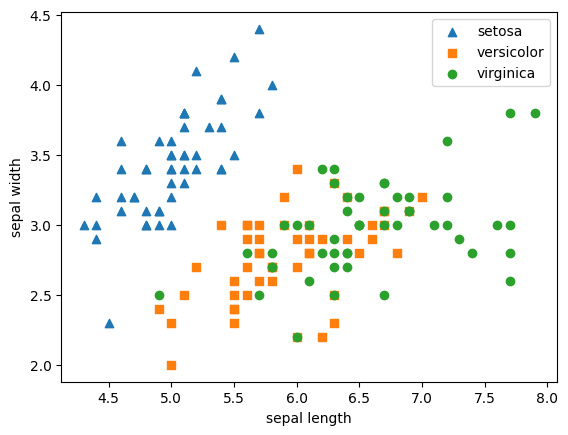

In [7]:
# setosa는 세모, versicolor는 네모, virginica는 동그라미
marker = ['^', 's', 'o']

for i, marker in enumerate(marker):
    x_data = iris_df[iris_data.target==i]['sepal_length']
    y_data = iris_df[iris_data.target==i]['sepal_width']
    plt.scatter(x_data, y_data, marker=marker, label=iris_data.target_names[i])

plt.legend()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.show()

# 2.스케일링
- PCA는 여러 속성의 값을 연산해야 하므로 속성의 스케일에 영향을 받는다.
- 여러 속성을 PCA로 압축하기 전에 각 속성값을 동일한 스케일로 변환하는 것이 필요하다.

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
iris_df.iloc[:,:-1]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [10]:
# target 값을 제외한 모든 속성 값을 StandardScaler를 이용해서 표준 정규 분포를 가지는 값들로 변환
scaler = StandardScaler()
scaler.fit(iris_df.iloc[:,:-1])
iris_scaled = scaler.transform(iris_df.iloc[:,:-1])

# 3.주성분 분석(PCA)

In [11]:
from sklearn.decomposition import PCA

In [12]:
# 변환할 차원의 수 : 2
pca = PCA(n_components=2)

In [13]:
iris_df.shape

(150, 5)

In [14]:
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)
print(iris_pca.shape)

(150, 2)


In [15]:
irispca_df = pd.DataFrame(iris_pca, columns=['pca_component_1', 'pca_component_2'])
irispca_df['target'] = iris_data.target
irispca_df.head()

,pca_component_1,pca_component_2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


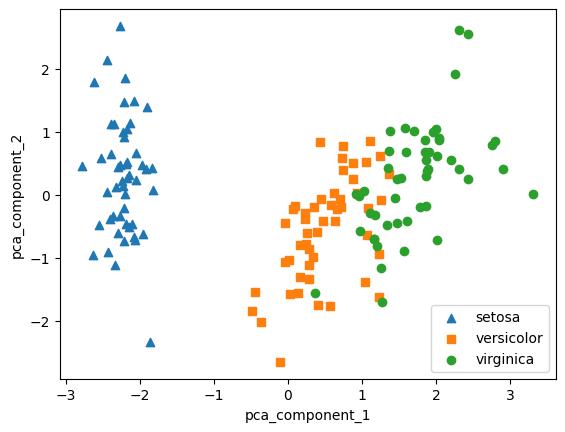

In [16]:

marker = ['^', 's', 'o']

for i, marker in enumerate(marker):
    x_data = irispca_df[irispca_df.target==i]['pca_component_1']
    y_data = irispca_df[irispca_df.target==i]['pca_component_2']
    plt.scatter(x_data, y_data, marker=marker, label=iris_data.target_names[i])

plt.legend()
plt.xlabel('pca_component_1')
plt.ylabel('pca_component_2')
plt.show()

- versicolor와 virginica는 pca_component1 축을 기반으로 서로 겹치는 부분이 일부 존재하지만, 비교적 잘 구분됨.

In [17]:
# 전체 변동성에서 개별 PCA 컴포넌트별로 차지하는 변동성 비율을 제공
# 처음 두 개 주성분만으로도 원래 데이터의 95%
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


- 랜덤포레스트 모델과 비교해보기

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [20]:
rfc = RandomForestClassifier(random_state=1)
scores = cross_val_score(rfc, iris_data.data, iris_data.target, scoring='accuracy', cv=3)

print('원본 데이터 교차 검증 개별 정확도:', scores)
print('원본 데이터 평균 정확도:', np.mean(scores))

원본 데이터 교차 검증 개별 정확도: [0.98 0.94 0.98]
원본 데이터 평균 정확도: 0.9666666666666667


In [ ]:
pca_X = irispca_df['pca_component_1', 'pca_component_2']
scores_pca = cross_val_score(rfc, pca_X, iris)
print('PCA 변환 데이터 교차 검증 개별 정확도:', )
print('PCA 변환 데이터 평균 정확도:',)

# 4.선형판별분석(LDA)
- 차원 축소 기법이자 분류 모델이다.
- PCA는 데이터의 분산을 기준으로 축을 찾는 반면, LDA는 클래스 분리를 극대화하는 축을 찾는다.

- PCA 와 다르게 LDA에서 유의해야 할 점은 LDA는 실제로는 PCA와 다르게 비지도학습이 아닌 지도학습이다.
- 즉, 클래스의 결정 값이 변환 시에 필요하다.

In [ ]:
# setosa는 세모, versicolor는 네모, virginica는 동그라미
marker = ['^', 's', 'o']

for i, marker in enumerate(marker):
    x_data = 
    y_data = 
    plt.scatter(x_data, y_data, marker=marker, label=iris_data.target_names[i])

plt.legend(loc='upper right')
plt.xlabel('')
plt.ylabel('')
plt.show()

# 5.특이값 분해(SVD)
- 모든 행렬에 적용 가능한 일반적인 차원 축소 기법
- PCA와 유사하며, 행렬을 세 개의 행렬로 분해하여 주요 패턴을 추출
- sklearn TruncatedSVD 클래스를 이용

- pca와 비교

In [ ]:
# Target값을 제외한 모든 속성 값을 StandardScaler를 이용해서 표준 정규 분포를 가지는 값들로 변환
scaler = StandardScaler()
scaler.fit(iris_df.iloc[:,:-1])
iris_scaled = scaler.transform(iris_df.iloc[:,:-1])

In [ ]:

fig, (ax1, ax2) = plt.subplots(figsize=(9,4), ncols=2)

ax1.scatter(x=, y=, c=)
ax2.scatter(x=, y=, c=)
ax1.set_title('SVD Transformed')
ax2.set_title('PCA Transformed')

plt.show()